In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import torchaudio
from IPython.display import Audio, display
from pathlib import Path

sns.set_theme(style="whitegrid")

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'captum_tcav').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise FileNotFoundError('Could not locate repo root containing captum_tcav/')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = REPO_ROOT / 'captum_tcav' / 'output' / 'tcav_scores_100X50.csv'

from captum_tcav.config import (
    concept_root,
    data_dir as CONFIG_DATA_DIR,
    model_dataset,
    model_entrypoint,
    model_name,
    model_repo,
    model_train_type,
)

DATA_DIR = Path(CONFIG_DATA_DIR)
CONCEPT_ROOT = Path(concept_root)

speaker_id = 'id00151'
n_examples = 5
def infer_target_frames() -> int:
    concept_dirs = sorted(path for path in CONCEPT_ROOT.iterdir() if path.is_dir())
    if not concept_dirs:
        raise FileNotFoundError(f'No concept directories found under {CONCEPT_ROOT}')
    first_files = sorted(concept_dirs[0].glob('*.npy'))
    if not first_files:
        raise FileNotFoundError(f'No concept npy files found under {concept_dirs[0]}')
    return int(np.load(first_files[0]).shape[1])

def normalize_frames(mel_3d: torch.Tensor, target_frames: int) -> torch.Tensor:
    current_frames = int(mel_3d.shape[-1])
    if current_frames == target_frames:
        return mel_3d
    if current_frames > target_frames:
        start = (current_frames - target_frames) // 2
        return mel_3d[..., start : start + target_frames]
    pad = target_frames - current_frames
    left = pad // 2
    right = pad - left
    return F.pad(mel_3d, (left, right), mode='constant', value=0.0)

target_frames = infer_target_frames()
redim_model = torch.hub.load(
    model_repo,
    model_entrypoint,
    model_name=model_name,
    train_type=model_train_type,
    dataset=model_dataset,
).eval()

print(f'Repo root: {REPO_ROOT}')
print(f'CSV path: {CSV_PATH}')
print(f'Data dir: {DATA_DIR}')
print(f'Concept root: {CONCEPT_ROOT}')
print(f'target_frames = {target_frames}')
print(f'Speaker: {speaker_id}')
print(f'n_examples = {n_examples}')

Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Repo root: /home/SpeakerRec/BioVoice/redimnet/tcav
CSV path: /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/output/tcav_scores_100X50.csv
Data dir: /home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac
Concept root: /home/SpeakerRec/BioVoice/concept/redimnet_concepts/concepts
target_frames = 301
Speaker: id00151
n_examples = 5


## 2. Load TCAV CSV and Speaker Summary

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Could not find CSV at {CSV_PATH}')

df = pd.read_csv(CSV_PATH)
speaker_df = df[df['speaker'] == speaker_id].copy()

if speaker_df.empty:
    raise ValueError(f'No CSV rows found for speaker {speaker_id}')

speaker_scores = speaker_df[['concept_name', 'magnitude', 'sign_count']].sort_values('magnitude', ascending=False)
strongest = speaker_scores.head(5)
weakest = speaker_scores.iloc[(speaker_scores['magnitude'].abs().argsort())].head(5)
most_negative = speaker_scores[speaker_scores['magnitude'] < 0].sort_values('magnitude').head(5)

print('Strongest concepts:')
display(strongest)
print('Weakest concepts:')
display(weakest)
print('Most negative concepts:')
display(most_negative)

Strongest concepts:


,concept_name,magnitude,sign_count
1036,short_dropping_steep_thick,0.012315,0.76
1031,long_rising_flat_thick,0.012305,0.74
1028,long_dropping_flat_thick,0.011596,0.72
1035,short_constant_thick,0.008791,0.72
1029,long_dropping_steep_thick,0.008442,0.68


Weakest concepts:


,concept_name,magnitude,sign_count
1030,long_dropping_steep_thin,0.004071,0.580000
1037,short_dropping_steep_thin,-0.004767,0.400000
1033,long_rising_steep_thin,-0.005040,0.420000
1032,long_rising_steep_thick,0.005182,0.580000
1034,random_0,-0.006155,0.376667


Most negative concepts:


,concept_name,magnitude,sign_count
1034,random_0,-0.006155,0.376667
1033,long_rising_steep_thin,-0.005040,0.420000
1037,short_dropping_steep_thin,-0.004767,0.400000


## 3. Discover Audio Files for the Speaker

In [3]:
speaker_dir = DATA_DIR / speaker_id
if not speaker_dir.exists():
    raise FileNotFoundError(f'Could not find speaker directory: {speaker_dir}')

audio_paths = sorted(speaker_dir.rglob("*.wav"))
audio_paths.extend(sorted(speaker_dir.rglob("*.m4a")))
audio_paths = sorted(audio_paths)

if not audio_paths:
    raise ValueError(f'No audio files found under {speaker_dir}')

selected_paths = audio_paths[:n_examples]
print(f'Found {len(audio_paths)} files, showing {len(selected_paths)}')
for path in selected_paths:
    print(path)

Found 137 files, showing 5
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00151/0rtXWNtBAGg/00001.m4a
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00151/0rtXWNtBAGg/00002.m4a
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00151/0rtXWNtBAGg/00003.m4a
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00151/2TA_9cYcNmw/00004.m4a
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00151/2Xw3vgyXJBY/00005.m4a


## 4. Plot Spectrograms

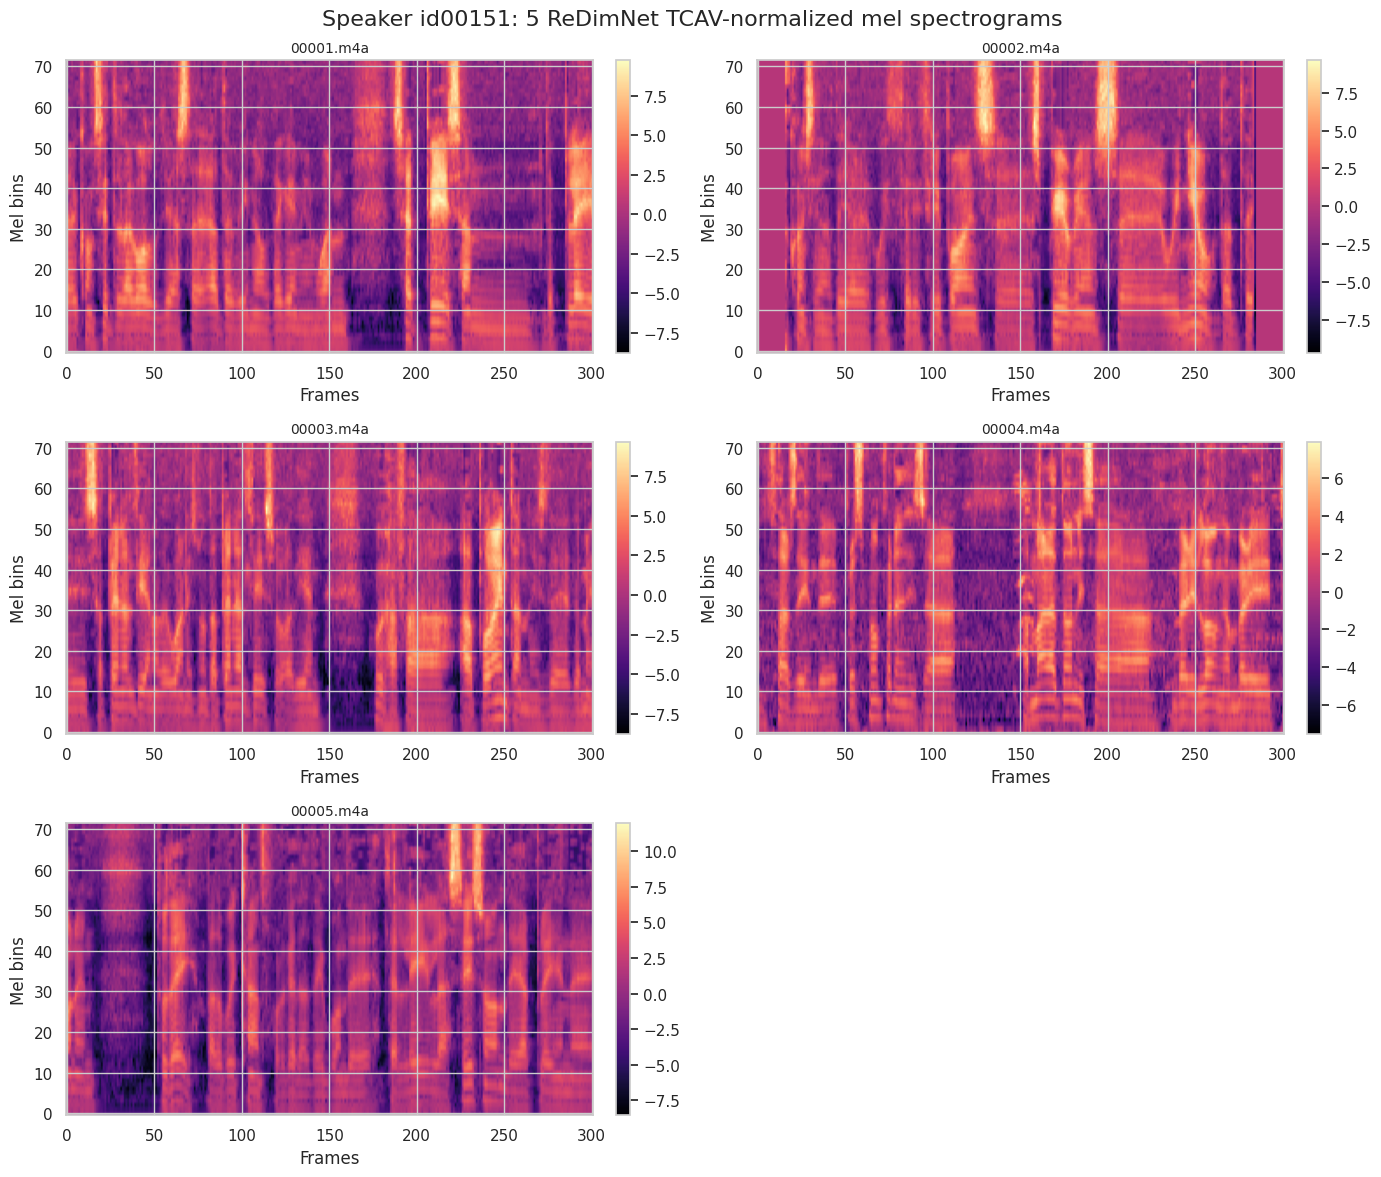

00001.m4a


00002.m4a


00003.m4a


00004.m4a


00005.m4a


In [ ]:
def load_mel_db(path: Path):
    waveform, sample_rate = torchaudio.load(str(path))
    waveform = waveform[:1, :].float()
    with torch.no_grad():
        mel = redim_model.spec(waveform)
    mel = normalize_frames(mel, target_frames)
    return mel.squeeze(0).detach().cpu().numpy()

n_cols = 2
n_rows = int(np.ceil(len(selected_paths) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

for ax, path in zip(axes.flat, selected_paths):
    mel_db = load_mel_db(path)
    image = ax.imshow(mel_db, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(path.name, fontsize=10)
    ax.set_xlabel('Frames')
    ax.set_ylabel('Mel bins')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.flat[len(selected_paths):]:
    ax.axis('off')

fig.suptitle(f'Speaker {speaker_id}: {len(selected_paths)} ReDimNet TCAV-normalized mel spectrograms', fontsize=16)
plt.tight_layout()
plt.show()

for path in selected_paths:
    audio_waveform, audio_sample_rate = torchaudio.load(str(path))
    audio_waveform = audio_waveform[:1, :].squeeze(0).detach().cpu()
    print(path.name)
    display(Audio(data=audio_waveform.numpy(), rate=audio_sample_rate, autoplay=False))